# Signed-Measure Distance

A signed measure is a finite signed sum of atoms,

$$
\mu=\sum_i m_i\delta_{x_i},\qquad
\nu=\sum_j n_j\delta_{y_j}.
$$

Write its Jordan decomposition as
$\mu=\mu^+-\mu^-$ and $\nu=\nu^+-\nu^-$. Since optimal transport moves
nonnegative mass, the signed difference is represented by two positive
measures:

$$
\mu-\nu=(\mu^+ + \nu^-) - (\nu^+ + \mu^-),
\qquad
A=\mu^+ + \nu^-,\quad B=\nu^+ + \mu^-.
$$

For positive measures

$$
A=\sum_i a_i\delta_{x_i},\qquad B=\sum_j b_j\delta_{y_j},
\qquad \sum_i a_i=\sum_j b_j,
$$

a coupling $\pi\in\Pi(A,B)$ is a positive measure on the product space whose
marginals are $A$ and $B$. In the discrete case,
$\pi=\sum_{i,j}\gamma_{ij}\delta_{(x_i,y_j)}$, where

$$
\gamma_{ij}\ge 0,\qquad
\sum_j\gamma_{ij}=a_i,
\qquad
\sum_i\gamma_{ij}=b_j.
$$

The default balanced distance is the total-mass $1$-Wasserstein objective

$$
\min_{\pi\in\Pi(A,B)}\int \|x-y\|_1\,d\pi(x,y)
=
\min_{\gamma\ge 0}\sum_{i,j}\gamma_{ij}\,\|x_i-y_j\|_1.
$$

For the integer weights used here, the code expands each atom into repeated
unit atoms. If $x_1,\ldots,x_N$ and $y_1,\ldots,y_N$ denote those repeated
atoms, the same problem has row and column sums equal to $1$:

$$
\min_{\gamma\in\mathbb{R}_+^{N\times N}}
\sum_{i=1}^N\sum_{j=1}^N \gamma_{ij}\,\|x_i-y_j\|_1
\quad\text{such that}\quad
\sum_j\gamma_{ij}=1,
\qquad
\sum_i\gamma_{ij}=1.
$$

Using probability-normalized weights would divide this total unit-mass
objective by $N$.

With `sliced=True`, `sm_distance` uses one-dimensional Wasserstein projections.
With `reg > 0` and `reg_m > 0`, it uses unbalanced Sinkhorn and penalizes mass
creation/destruction.

In [1]:
import numpy as np
import ot

import multipers as mp
import matplotlib.pylab as plt
from multipers.data import noisy_annulus
from multipers.distances import sm2diff, sm_distance

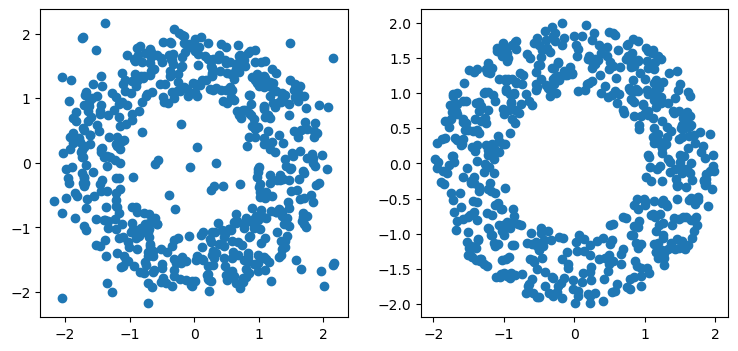

In [2]:
# Point clouds first. Same pipeline as the other distance notebooks, different
# noise profile.
X = noisy_annulus(500, 100)
Y = noisy_annulus(600, 0)

fig, (a, b) = plt.subplots(1, 2, figsize=(9, 4))
a.scatter(*X.T)
a.set_aspect(1)

b.scatter(*Y.T)
b.set_aspect(1)
plt.show()

Build Delaunay-codensity filtrations for both point clouds. `DelaunayCodensity`
is the codensity specialization of the Delaunay lower-star construction; see
the [Delaunay Lowerstar filtrations](../filtrations/function_delaunay.ipynb)
notebook for construction details. We then take
[minimal presentations](../ops/minimal_presentations_resolutions.ipynb) in
degree 1.

In [3]:
f1 = mp.filtrations.DelaunayCodensity(points=X, bandwidth=0.1, reduce_degree=1).minpres(
    1,
    full_resolution=1,
)
f2 = mp.filtrations.DelaunayCodensity(points=Y, bandwidth=0.1, reduce_degree=1).minpres(
    1,
    full_resolution=1,
)

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


The [Hilbert signed measure](../invariants/signed_measure.ipynb) is the sparse
Möbius inversion whose cumulative lower-set sum is the
[Hilbert function](../invariants/hilbert_function.ipynb). Positive and
negative masses encode the Jordan decomposition used internally by
`sm_distance`.

/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/multipers/plots.py:189: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/dlapous/micromamba/envs/313/lib/python3.13/site-packages/multipers/plots.py:189: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


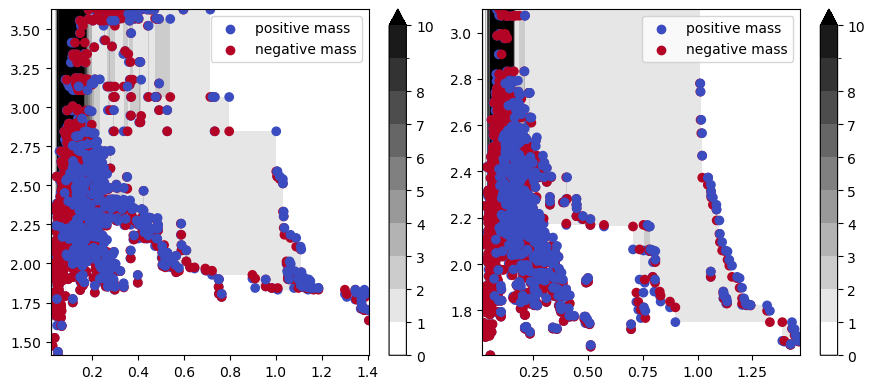

In [4]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9, 4))
plt.sca(a)
mp.invariants.hilbert_function(f1, plot=True)
(sm1,) = mp.signed_measure(f1, invariant="hilbert", plot=True)
plt.sca(b)
mp.invariants.hilbert_function(f2, plot=True)
(sm2,) = mp.signed_measure(f2, invariant="hilbert", plot=True)
plt.show()

Here is the exact default path on a small balanced example. We keep integer
weights because the implementation expands weights into repeated unit atoms.

In [5]:
toy_sm1 = (
    np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]]),
    np.array([2, -1, 1]),
)
toy_sm2 = (
    np.array([[0.2, 0.1], [0.8, 0.2], [0.1, 0.9]]),
    np.array([1, -2, 3]),
)

`sm2diff` forms the positive measures $A=\mu^+ + \nu^-$ and
$B=\nu^+ + \mu^-$. Each row below is one repeated unit-mass atom.

In [6]:
x, y = sm2diff(toy_sm1, toy_sm2)
x.shape, y.shape

((5, 2), (5, 2))

The check below uses the same ground costs
$C_{ij}=\|x_i-y_j\|_1$. A probability-normalized coupling has marginals
$1/N$ instead of $1$, so its optimum is $1/N$ times the total unit-mass
objective above. Multiplying by `len(x)` recovers the signed-measure distance.

In [7]:
cost = np.linalg.norm(x[:, None, :] - y[None, :, :], ord=1, axis=2)
pot_reproduction = ot.lp.emd2([], [], M=cost) * len(x)
multipers_default = sm_distance(toy_sm1, toy_sm2)

np.testing.assert_allclose(multipers_default, pot_reproduction)
{
    "sm_distance default": multipers_default,
    "sm2diff + ot.lp.emd2": pot_reproduction,
}

{'sm_distance default': 3.3, 'sm2diff + ot.lp.emd2': 3.3}

The two Hilbert signed measures below have thousands of atoms, so the exact
dense EMD default is not the practical choice for this example. Instead, we use
two scalable variants of signed-measure optimal transport: sliced Wasserstein
for a cheap projection average and unbalanced Sinkhorn for an entropic transport
approximation with mass relaxation.

In [8]:
sm1[0].shape, sm2[0].shape

((2870, 2), (3192, 2))

In [9]:
sliced_distance = sm_distance(
    sm1,
    sm2,
    sliced=True,
    num_directions=32,
    seed=1,
)
sinkhorn_unbalanced_distance = sm_distance(
    sm1,
    sm2,
    reg=0.05,
    reg_m=1.0,
    numItermax=1000,
)

{
    "sliced signed-measure distance": sliced_distance,
    "unbalanced Sinkhorn signed-measure distance": sinkhorn_unbalanced_distance,
}

{'sliced signed-measure distance': np.float64(3.7455380239358274),
 'unbalanced Sinkhorn signed-measure distance': np.float64(0.07408153777771148)}